In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%autosave 0
    
import logging
logging.basicConfig(format='%(asctime)s %(levelname)s:%(message)s', level=logging.ERROR, datefmt='%I:%M:%S')

import os
import sys
import numpy as np
import pandas as pd
import sdata
from sdata.metadata import extract_name_unit
from sdata.timestamp import TimeStamp
import uuid
import openpyxl
import matplotlib.pyplot as plt
import datetime
import re
modulepath = os.getcwd()
modulepath

Autosave disabled


'/home/ingolf.lepenies/projects/sdata/ipynb'

In [2]:
today = datetime.datetime.today()
todaystr = datetime.date(today.year, today.month, today.day).isoformat()
todaystr

'2020-12-10'

In [3]:
TimeStamp(todaystr).utc

'2020-12-10T00:00:00+00:00'

In [4]:
workpath = "/home/ingolf.lepenies/projects/sdata_import/data/nist_111256_823-UT_H_Steel/"
workpath
os.listdir(workpath)

['medmnsteel_10mps_2_rd.json',
 'medmnsteel_1mps_1_rd.csv',
 'medmnsteel_10mps_1_rd.csv',
 'medmnsteel_0.01mps_1_rd.csv',
 'medmnsteel_0.01mps_2_rd.csv',
 'medmnsteel_1mps_2_rd.csv',
 'MedMnSteel_se_tech.png',
 'medmnsteel_10mps_1_rd.json',
 'MedMnSteel_se_tech.pdf',
 'medmnsteel_0.1mps_1_rd.json',
 'medmnsteel_10mps_2_rd.xlsx',
 'MedMnSteel_Fu.pdf',
 'medmnsteel_10mps_2_rd.csv',
 'medmnsteel_10mps_1_rd.xlsx',
 'medmnsteel_0.01mps_1_rd.xlsx',
 'MedMnSteel_se_true.png',
 'medmnsteel_1mps_1_rd.xlsx',
 'medmnsteel_1mps_2_rd.xlsx',
 'medmnsteel_0.1mps_2_rd.csv',
 'Med_Mn_S70_CMAT_LGH_edited.xlsx',
 'medmnsteel_1mps_1_rd.json',
 'MedMnSteel_se_true.pdf',
 'README.md',
 'medmnsteel_0.1mps_2_rd.json',
 'medmnsteel_0.01mps_2_rd.json',
 'medmnsteel_0.01mps_2_rd.xlsx',
 'medmnsteel_0.1mps_1_rd.xlsx',
 'medmnsteel_0.1mps_2_rd.xlsx',
 'MedMnSteel_fu.png',
 '20mm_HighRate_TensileGeometry.pdf',
 'MedMnSteel_fu.pdf',
 'medmnsteel_0.1mps_1_rd.csv',
 'medmnsteel_1mps_2_rd.json',
 'medmnsteel_0.01mps_1_

In [5]:
filename = "Med_Mn_S70_CMAT_LGH_edited.xlsx"
filepath = os.path.join(workpath, filename)
filepath

'/home/ingolf.lepenies/projects/sdata_import/data/nist_111256_823-UT_H_Steel/Med_Mn_S70_CMAT_LGH_edited.xlsx'

In [6]:
wb = openpyxl.load_workbook(filename=filepath)
sheet_names = wb.sheetnames
sheet_names

['10mps(1)-RD',
 '10mps(2)-RD',
 '1mps(1)-RD',
 '1mps(2)-RD',
 '0.1mps(1)-RD',
 '0.1mps(2)-RD',
 '0.01mps(1)-RD',
 '0.01mps(2)-RD',
 'eng(stressvsstrain)-RD']

In [7]:
def get_name(value):
    pattern4 = r'([\w\s\.]+)\((\w)\)'
    match4 = re.search(pattern4, value)
    match4
    if match4:
        name = match4.group(1)
        unit = match4.group(2)
        print(name, unit)
        return "_".join([name, unit, "RD"])
    else:
        return value
for sheet_name in sheet_names:
    print(get_name(sheet_name))

10mps 1
10mps_1_RD
10mps 2
10mps_2_RD
1mps 1
1mps_1_RD
1mps 2
1mps_2_RD
0.1mps 1
0.1mps_1_RD
0.1mps 2
0.1mps_2_RD
0.01mps 1
0.01mps_1_RD
0.01mps 2
0.01mps_2_RD
eng(stressvsstrain)-RD


In [8]:
description = """# High strain rate data for Medium Mn 2 (10 Wt. % Mn) Steel

nist_111256_823_UT_H_Steel

## Autors

Hector, Lou
Alturk, Rakan

## Description

A General Motors Instron VHS 2-Column Servo-Hydraulic Test Unit with High Speed Stereo Digital Image Correlation for strain measurement and dual strain gauges for load measurement were used. Materials were tested at room temperature and nominal strain rate of 0.5/s, 5/s, 50/s and 500/s. Data file consists of a true stress, true strain, engineering stress and engineering strain data.

## URI
 
* http://hdl.handle.net/11256/823
* https://materialsdata.nist.gov/handle/11256/823

## Collections

    High Strain Rate Data Results Generated at GM R&D

## Lizenz

Creative Commons Lizenz

"""

In [9]:
mapper = {'Time (s)':'time',
 'Extension (mm)':'displacement',
 'Load (kN)':'force',
 'Engineering Strain':'eps_tech',
 'Engineering Stress (MPa)':'sig_tech',
 'True Strain':'eps_true',
 'True Stress (MPa)':'sig_true'}
mapper


{'Time (s)': 'time',
 'Extension (mm)': 'displacement',
 'Load (kN)': 'force',
 'Engineering Strain': 'eps_tech',
 'Engineering Stress (MPa)': 'sig_tech',
 'True Strain': 'eps_true',
 'True Stress (MPa)': 'sig_true'}

In [10]:
columns = {'time': {'name': 'time',
          'value': None,
          'unit': 's',
          'dtype': 'float',
          'description': 'Time',
          'label': '$t$'},
'displacement': {'name': 'displacement',
          'value': None,
          'unit': 'mm',
          'dtype': 'float',
          'description': 'Extension',
          'label': '$u$'},
'force': {'name': 'force',
          'value': None,
          'unit': 'kN',
          'dtype': 'float',
          'description': 'Load',
          'label': '$F$'},
'eps_tech': {'name': 'eps_tech',
          'value': None,
          'unit': '-',
          'dtype': 'float',
          'description': 'Engineering Strain',
          'label': r'$\varepsilon_{tech}$'},
'sig_tech': {'name': 'sig_tech',
          'value': None,
          'unit': 'MPa',
          'dtype': 'float',
          'description': 'Engineering Stress',
          'label': r'$\sigma_{tech}$'},
'eps_true': {'name': 'eps_true',
          'value': None,
          'unit': '-',
          'dtype': 'float',
          'description': 'True Strain',
          'label': r'$\sigma_{true}$'},
'sig_true': {'name': 'sig_true',
          'value': None,
          'unit': 'MPa',
          'dtype': 'float',
          'description': 'True Stress',
          'label': r'$\varepsilon_{true}$'},
                    }
columns

{'time': {'name': 'time',
  'value': None,
  'unit': 's',
  'dtype': 'float',
  'description': 'Time',
  'label': '$t$'},
 'displacement': {'name': 'displacement',
  'value': None,
  'unit': 'mm',
  'dtype': 'float',
  'description': 'Extension',
  'label': '$u$'},
 'force': {'name': 'force',
  'value': None,
  'unit': 'kN',
  'dtype': 'float',
  'description': 'Load',
  'label': '$F$'},
 'eps_tech': {'name': 'eps_tech',
  'value': None,
  'unit': '-',
  'dtype': 'float',
  'description': 'Engineering Strain',
  'label': '$\\varepsilon_{tech}$'},
 'sig_tech': {'name': 'sig_tech',
  'value': None,
  'unit': 'MPa',
  'dtype': 'float',
  'description': 'Engineering Stress',
  'label': '$\\sigma_{tech}$'},
 'eps_true': {'name': 'eps_true',
  'value': None,
  'unit': '-',
  'dtype': 'float',
  'description': 'True Strain',
  'label': '$\\sigma_{true}$'},
 'sig_true': {'name': 'sig_true',
  'value': None,
  'unit': 'MPa',
  'dtype': 'float',
  'description': 'True Stress',
  'label': '$\\var

In [ ]:
sheet_name = sheet_names[0]
matname = "MedMnSteel"
def read_test0(sheet_name):
    os_sheet_name = get_name(sheet_name)
    df_meta = pd.read_excel(filepath, usecols=[0,1], 
                            sheet_name=sheet_name)
    df_meta.dropna(inplace=True)
    df_meta.columns=["name", "value"]
    d = dict(df_meta.values.tolist())
    m = sdata.Metadata.from_dict(d)
    df= pd.read_excel(filepath, usecols=[4,5,6,7,8,9,10],
                        skiprows=1,
                        sheet_name=sheet_name)
#     df.dropna(inplace=True)
#     df.rename(columns=mapper, inplace=True)
#     testname = matname+"_" + os_sheet_name
    s = sdata.Data(name=testname,
                   table=df, 
                   uuid=sdata.uuid_from_str(testname+TimeStamp(todaystr).utc),
                   description=description)
    for x in m.to_dict().values():
        name, unit = extract_name_unit(x["name"])
        x["name"] = name
        x["unit"] = unit
        try:
            x["value"] = float(x["value"])
            x["dtype"] = "float"
        except:
            pass
#         print(x)
        s.metadata.add(**x)
    for col in columns.values():
        s.metadata.add(**col)
    s.metadata.add("name", value=testname, label=sheet_name)
    s.metadata.add("License", "Creative Commons Lizenz")
    s.metadata.add("Source", "https://materialsdata.nist.gov/handle/11256/823")
#     s.metadata.add("sdata_date", TimeStamp(todaystr).utc, dtype="timestamp")
    s.metadata.add("sdata_date", TimeStamp(todaystr).utc)
    
    return s
s = read_test(sheet_name)
s.metadata.df

In [11]:
sheet_name = sheet_names[0]
matname = "MedMnSteel"
def read_test(sheet_name):
    os_sheet_name = get_name(sheet_name)
    df_meta = pd.read_excel(filepath, usecols=[0,1], 
                            sheet_name=sheet_name)
    df_meta.dropna(inplace=True)
    df_meta.columns=["name", "value"]
    d = dict(df_meta.values.tolist())
    m = sdata.Metadata.from_dict(d)
    df= pd.read_excel(filepath, usecols=[4,5,6,7,8,9,10],
                        skiprows=1,
                        sheet_name=sheet_name)
    df.dropna(inplace=True)
    df.rename(columns=mapper, inplace=True)
    testname = matname+"_" + os_sheet_name
    s = sdata.Data(name=testname,
                   table=df, 
                   uuid=sdata.uuid_from_str(testname+TimeStamp(todaystr).utc),
                   description=description)
    for x in m.to_dict().values():
        name, unit = extract_name_unit(x["name"])
        x["name"] = name
        x["unit"] = unit
        try:
            x["value"] = float(x["value"])
            x["dtype"] = "float"
        except:
            pass
#         print(x)
        s.metadata.add(**x)
    for col in columns.values():
        s.metadata.add(**col)
    s.metadata.add("name", value=testname, label=sheet_name)
    s.metadata.add("License", "Creative Commons Lizenz")
    s.metadata.add("Source", "https://materialsdata.nist.gov/handle/11256/823")
#     s.metadata.add("sdata_date", TimeStamp(todaystr).utc, dtype="timestamp")
    s.metadata.add("sdata_date", TimeStamp(todaystr).utc)
    
    return s
s = read_test(sheet_name)
s.metadata.df

10mps 1


,name,value,dtype,unit,description,label
key,,,,,,
sdata_version,sdata_version,0.9.2,str,,,
name,name,MedMnSteel_10mps_1_RD,str,-,,10mps(1)-RD
uuid,uuid,2b8fe212a41a30a4955f869cfdde046c,str,-,,
Test Name,Test Name,10mps(1),str,,,
Material,Material,Med Mn Steel,str,,,
Thickness,Thickness,1.25,float,mm,,
Width,Width,7.43,float,mm,,
Gauge Length,Gauge Length,20,float,mm,,
Target Strain Rate,Target Strain Rate,500,float,1/s,,


In [12]:
s.metadata.get("Target Strain Rate")

(Attr'Target Strain Rate':500.0(float))

In [13]:
s.metadata.to_list()

[['sdata_version', '0.9.2', 'str', '', '', ''],
 ['name', 'MedMnSteel_10mps_1_RD', 'str', '-', '', '10mps(1)-RD'],
 ['uuid', '2b8fe212a41a30a4955f869cfdde046c', 'str', '-', '', ''],
 ['Test Name', '10mps(1)', 'str', '', '', ''],
 ['Material', 'Med Mn Steel', 'str', '', '', ''],
 ['Thickness', 1.25, 'float', 'mm', '', ''],
 ['Width', 7.43, 'float', 'mm', '', ''],
 ['Gauge Length', 20.0, 'float', 'mm', '', ''],
 ['Target Strain Rate', 500.0, 'float', '1/s', '', ''],
 ['Orientation', 'RD', 'str', '', '', ''],
 ['time', nan, 'float', 's', 'Time', '$t$'],
 ['displacement', nan, 'float', 'mm', 'Extension', '$u$'],
 ['force', nan, 'float', 'kN', 'Load', '$F$'],
 ['eps_tech',
  nan,
  'float',
  '-',
  'Engineering Strain',
  '$\\varepsilon_{tech}$'],
 ['sig_tech', nan, 'float', 'MPa', 'Engineering Stress', '$\\sigma_{tech}$'],
 ['eps_true', nan, 'float', '-', 'True Strain', '$\\sigma_{true}$'],
 ['sig_true', nan, 'float', 'MPa', 'True Stress', '$\\varepsilon_{true}$'],
 ['License', 'Creative 

In [14]:
s.describe()

,0
metadata,20
table_rows,23
table_columns,7
description,731


In [15]:
s.df.head(3)

,time,displacement,force,eps_tech,sig_tech,eps_true,sig_true
index,,,,,,,
0,0.00000,0.000000,-0.346456,0.000000,-31.51045,0.000000,-31.510450
1,0.00005,0.000138,-0.309855,0.000008,-44.92826,0.000008,-44.928624
2,0.00010,0.001084,-0.329818,0.000064,-35.57331,0.000064,-35.575577


In [16]:
# s.metadata.to_dict()

In [17]:
s.osname

'medmnsteel_10mps_1_rd'

In [18]:
datas = []
for sheet_name in sheet_names[:-1]:
    data = read_test(sheet_name)
    datas.append(data)
    print(data)
    data.to_xlsx(os.path.join(workpath, data.osname+".xlsx"))
    data.to_json(filepath=os.path.join(workpath, data.osname+".json"))
    data.to_csv(os.path.join(workpath, data.osname+".csv"))

10mps 1
(Data 'MedMnSteel_10mps_1_RD':2b8fe212a41a30a4955f869cfdde046c)
10mps 2
(Data 'MedMnSteel_10mps_2_RD':2d7561f7fe493e00841fce986690d685)
1mps 1
(Data 'MedMnSteel_1mps_1_RD':9e585b18aa653b788d496b92737d9458)
1mps 2
(Data 'MedMnSteel_1mps_2_RD':6055233667c139bb9a83c42d60a305cd)
0.1mps 1
(Data 'MedMnSteel_0.1mps_1_RD':84c85e9b780f3b2a8e3f15d752b02915)
0.1mps 2
(Data 'MedMnSteel_0.1mps_2_RD':208270a53da939668f7872f505447e15)
0.01mps 1
(Data 'MedMnSteel_0.01mps_1_RD':7256421e5abf3660aaf4a48016d12d3f)
0.01mps 2
(Data 'MedMnSteel_0.01mps_2_RD':611cc06d704739e0ad1bb9e145d77c9e)


In [19]:
d = data.from_json(filepath=os.path.join(workpath, data.osname+".json"))
d.describe()

,0
metadata,20
table_rows,279
table_columns,7
description,731


/home/ingolf.lepenies/anaconda3/envs/sfem3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/ingolf.lepenies/anaconda3/envs/sfem3/lib/python3.7/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/home/ingolf.lepenies/anaconda3/envs/sfem3/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


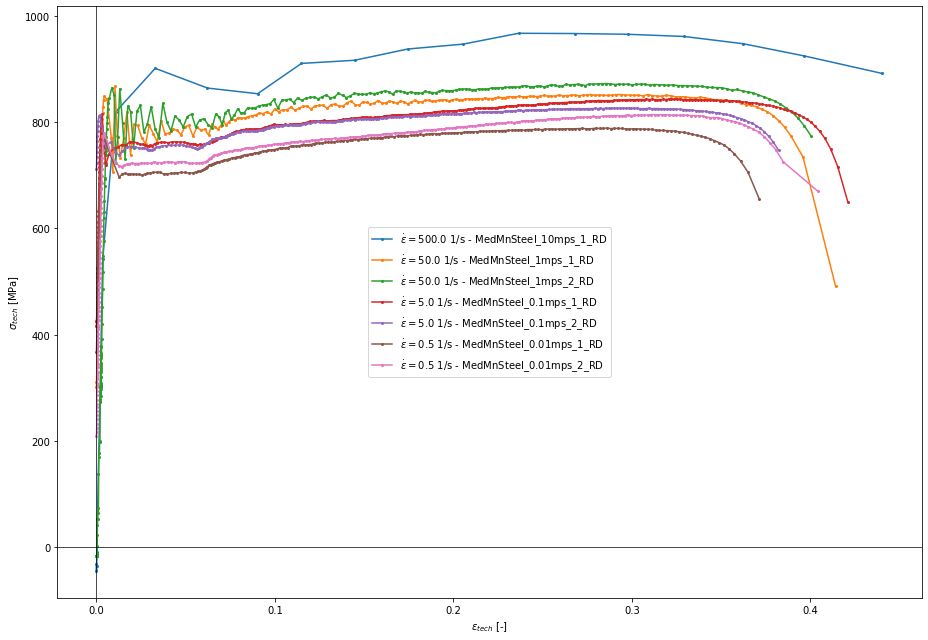

In [20]:
fig, ax = plt.subplots(figsize=[13,9])
plotname = matname + "_se_tech"
for data in datas:
    if data.name=="MedMnSteel_10mps_2_RD":
        continue
#     print(data)
    sr = data.metadata.get("Target Strain Rate")
    x_name = "displacement"
    y_name = "force"
    x_name = "eps_tech"
    y_name = "sig_tech"
    df = data.df
    ax.plot(df[x_name], df[y_name], 
            label=r"$\dot \varepsilon = {1.value}$ {1.unit} - {0}".format(data.name, sr), 
            marker="o", ms=2)

ax.legend()

x_attr = data.metadata.get(x_name)
y_attr = data.metadata.get(y_name)

ax.set_xlabel(r"{0.label} [{0.unit}]".format(x_attr))
ax.set_ylabel(r"{0.label} [{0.unit}]".format(y_attr))
ax.axhline(0, alpha=.7, lw=1, c="k")
ax.axvline(0, alpha=.7, lw=1, c="k")
fig.tight_layout()
fig.savefig(os.path.join(workpath, plotname+".png"))
fig.savefig(os.path.join(workpath, plotname+".pdf"))

(Data 'MedMnSteel_10mps_1_RD':2b8fe212a41a30a4955f869cfdde046c)
(Data 'MedMnSteel_1mps_1_RD':9e585b18aa653b788d496b92737d9458)
(Data 'MedMnSteel_1mps_2_RD':6055233667c139bb9a83c42d60a305cd)
(Data 'MedMnSteel_0.1mps_1_RD':84c85e9b780f3b2a8e3f15d752b02915)
(Data 'MedMnSteel_0.1mps_2_RD':208270a53da939668f7872f505447e15)
(Data 'MedMnSteel_0.01mps_1_RD':7256421e5abf3660aaf4a48016d12d3f)
(Data 'MedMnSteel_0.01mps_2_RD':611cc06d704739e0ad1bb9e145d77c9e)


/home/ingolf.lepenies/anaconda3/envs/sfem3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/ingolf.lepenies/anaconda3/envs/sfem3/lib/python3.7/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/home/ingolf.lepenies/anaconda3/envs/sfem3/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


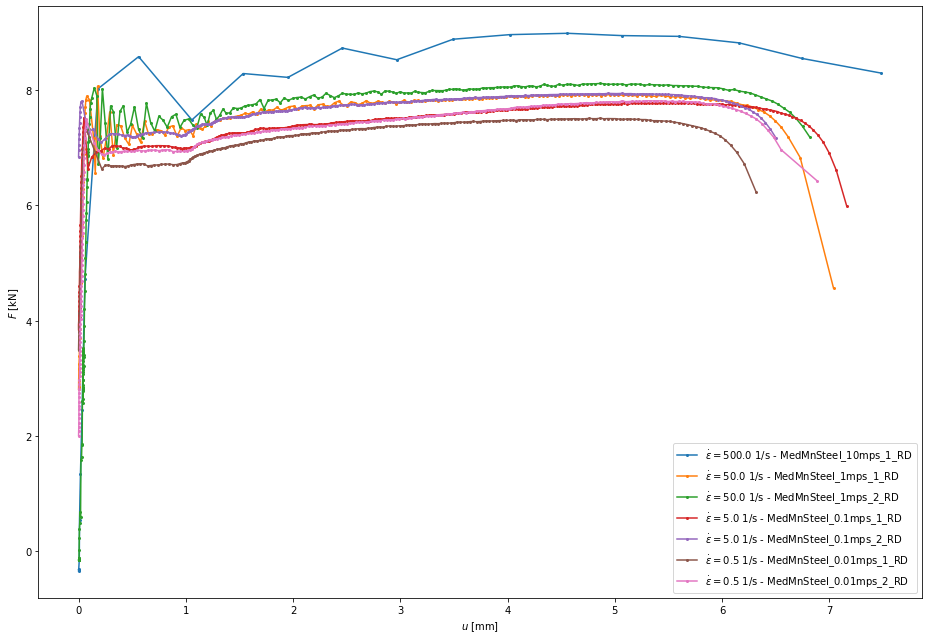

In [21]:
fig, ax = plt.subplots(figsize=[13,9])
plotname = matname + "_fu"
for data in datas:
    if data.name=="MedMnSteel_10mps_2_RD":
        continue
    print(data)
    sr = data.metadata.get("Target Strain Rate")
    x_name = "displacement"
    y_name = "force"
    df = data.df
    ax.plot(df[x_name], df[y_name], 
            label=r"$\dot \varepsilon = {1.value}$ {1.unit} - {0}".format(data.name, sr), 
            marker="o", ms=2)

ax.legend()

x_attr = data.metadata.get(x_name)
y_attr = data.metadata.get(y_name)

ax.set_xlabel(r"{0.label} [{0.unit}]".format(x_attr))
ax.set_ylabel(r"{0.label} [{0.unit}]".format(y_attr))
fig.tight_layout()
fig.savefig(os.path.join(workpath, plotname+".png"))
fig.savefig(os.path.join(workpath, plotname+".pdf"))

(Data 'MedMnSteel_10mps_1_RD':2b8fe212a41a30a4955f869cfdde046c)
(Data 'MedMnSteel_1mps_1_RD':9e585b18aa653b788d496b92737d9458)
(Data 'MedMnSteel_1mps_2_RD':6055233667c139bb9a83c42d60a305cd)
(Data 'MedMnSteel_0.1mps_1_RD':84c85e9b780f3b2a8e3f15d752b02915)
(Data 'MedMnSteel_0.1mps_2_RD':208270a53da939668f7872f505447e15)
(Data 'MedMnSteel_0.01mps_1_RD':7256421e5abf3660aaf4a48016d12d3f)
(Data 'MedMnSteel_0.01mps_2_RD':611cc06d704739e0ad1bb9e145d77c9e)


/home/ingolf.lepenies/anaconda3/envs/sfem3/lib/python3.7/site-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x[:, None]
/home/ingolf.lepenies/anaconda3/envs/sfem3/lib/python3.7/site-packages/matplotlib/axes/_base.py:276: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  x = x[:, np.newaxis]
/home/ingolf.lepenies/anaconda3/envs/sfem3/lib/python3.7/site-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


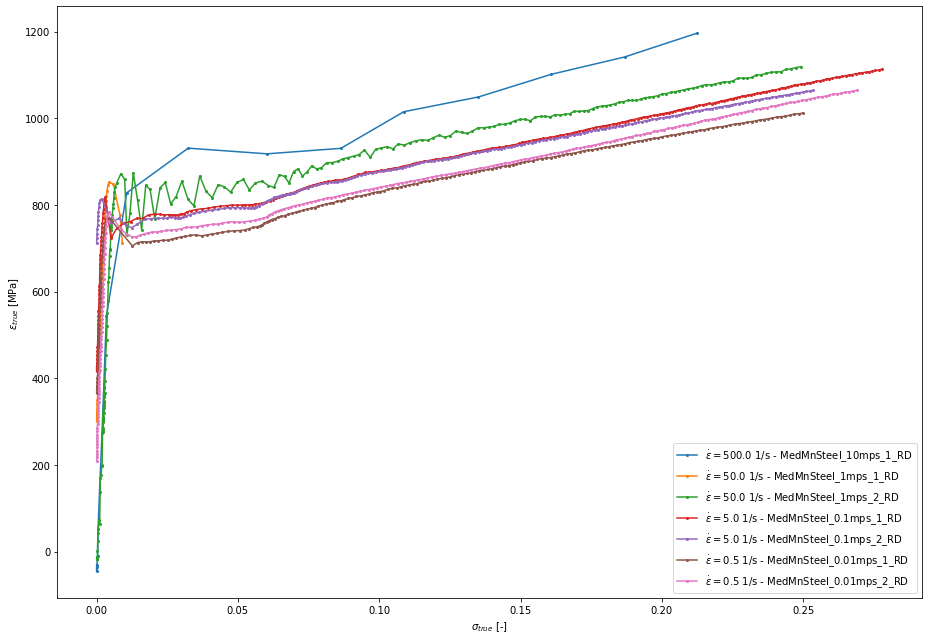

In [22]:
fig, ax = plt.subplots(figsize=[13,9])
plotname = matname + "_se_true"
for data in datas:
    if data.name=="MedMnSteel_10mps_2_RD":
        continue
    print(data)
    sr = data.metadata.get("Target Strain Rate")
    x_name = "eps_true"
    y_name = "sig_true"
    df = data.df
    
    idxmax = df["force"].argmax()
    ax.plot(df[x_name][:idxmax], df[y_name][:idxmax], 
            label=r"$\dot \varepsilon = {1.value}$ {1.unit} - {0}".format(data.name, sr), 
            marker="o", ms=2)

ax.legend()

x_attr = data.metadata.get(x_name)
y_attr = data.metadata.get(y_name)

ax.set_xlabel(r"{0.label} [{0.unit}]".format(x_attr))
ax.set_ylabel(r"{0.label} [{0.unit}]".format(y_attr))
fig.tight_layout()
fig.savefig(os.path.join(workpath, plotname+".png"))
fig.savefig(os.path.join(workpath, plotname+".pdf"))